In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Normalize + add channel dimension
x_train = (x_train.astype("float32") / 255.0)[..., None]
x_test = (x_test.astype("float32") / 255.0)[..., None]

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28, 1) (60000,)
Test : (10000, 28, 28, 1) (10000,)


In [3]:
def build_cnn(input_shape=(28,28,1), filters=(32,64), kernel_size=3,
              dropout=False, lr=1e-3, batch_norm=False):

    model = keras.Sequential()
    model.add(layers.Input(shape=input_shape))

    # Block 1
    model.add(layers.Conv2D(filters[0], kernel_size, padding="same", activation="relu"))
    if batch_norm:
        model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    if dropout:
        model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(filters[1], kernel_size, padding="same", activation="relu"))
    if batch_norm:
        model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    if dropout:
        model.add(layers.Dropout(0.25))

    # Classifier
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation="relu"))
    if dropout:
        model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [4]:
def train_and_evaluate(model, batch_size=64, epochs=10):
    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=2
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    print(f"\nTest Accuracy: {test_acc*100:.2f}%")

    return history, test_acc

In [5]:
def plot_history(history):
    # Loss
    plt.figure()
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.legend()
    plt.title("Loss")
    plt.show()

    # Accuracy
    plt.figure()
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.legend()
    plt.title("Accuracy")
    plt.show()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 - 61s - 81ms/step - accuracy: 0.8366 - loss: 0.4508 - val_accuracy: 0.8842 - val_loss: 0.3260
Epoch 2/10
750/750 - 57s - 76ms/step - accuracy: 0.8934 - loss: 0.2961 - val_accuracy: 0.8972 - val_loss: 0.2817
Epoch 3/10
750/750 - 56s - 75ms/step - accuracy: 0.9087 - loss: 0.2489 - val_accuracy: 0.9046 - val_loss: 0.2609
Epoch 4/10
750/750 - 59s - 79ms/step - accuracy: 0.9205 - loss: 0.2161 - val_accuracy: 0.9118 - val_loss: 0.2477
Epoch 5/10
750/750 - 80s - 107ms/step - accuracy: 0.9307 - loss: 0.1891 - val_accuracy: 0.9141 - val_loss: 0.2422
Epoch 6/10
750/750 - 56s - 74ms/step - accuracy: 0.9406 - loss: 0.1641 - val_accuracy: 0.9156 - val_loss: 0.2511
Epoch 7/10
750/750 - 82s - 110ms/step - accuracy: 0.9493 - loss: 0.1417 - val_accuracy: 0.9168 - val_loss: 0.2522
Epoch 8/10
750/750 - 81s - 109ms/step - accuracy: 0.9573 - loss: 0.1212 - val_accuracy: 0.9160 - val_loss: 0.2739
Epoch 9/10
750/750 - 57s - 76ms/step - accuracy: 0.9620 - loss: 0.1071 - val_accuracy: 0.9107

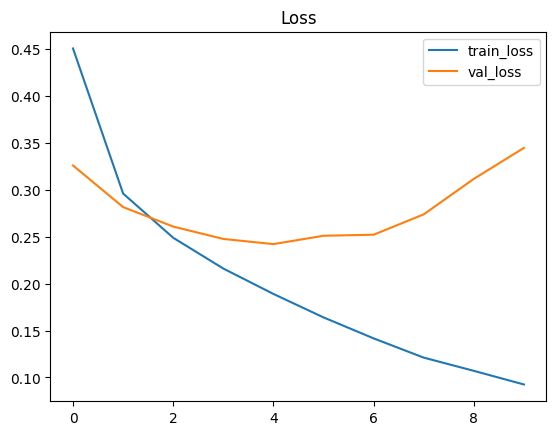

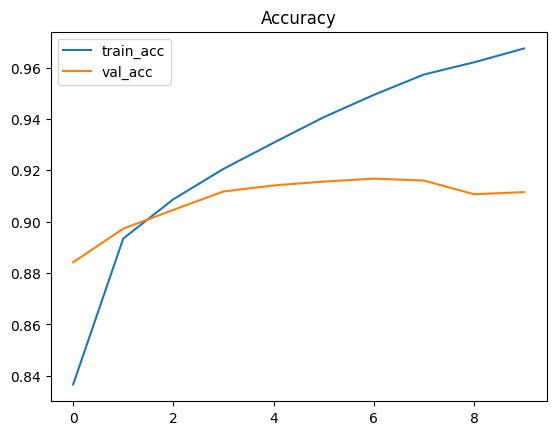

In [6]:
model_base = build_cnn(filters=(32,64), kernel_size=3, dropout=False)
model_base.summary()

history_base, acc_base = train_and_evaluate(model_base)
plot_history(history_base)

In [7]:
model_e1 = build_cnn(filters=(16,32))
history_e1, acc_e1 = train_and_evaluate(model_e1)

Epoch 1/10
750/750 - 33s - 44ms/step - accuracy: 0.8222 - loss: 0.4918 - val_accuracy: 0.8737 - val_loss: 0.3569
Epoch 2/10
750/750 - 30s - 41ms/step - accuracy: 0.8830 - loss: 0.3266 - val_accuracy: 0.8917 - val_loss: 0.3056
Epoch 3/10
750/750 - 33s - 44ms/step - accuracy: 0.8979 - loss: 0.2808 - val_accuracy: 0.9003 - val_loss: 0.2786
Epoch 4/10
750/750 - 40s - 53ms/step - accuracy: 0.9087 - loss: 0.2497 - val_accuracy: 0.9068 - val_loss: 0.2639
Epoch 5/10
750/750 - 30s - 40ms/step - accuracy: 0.9169 - loss: 0.2250 - val_accuracy: 0.9085 - val_loss: 0.2590
Epoch 6/10
750/750 - 30s - 41ms/step - accuracy: 0.9255 - loss: 0.2048 - val_accuracy: 0.9098 - val_loss: 0.2539
Epoch 7/10
750/750 - 34s - 45ms/step - accuracy: 0.9327 - loss: 0.1859 - val_accuracy: 0.9114 - val_loss: 0.2539
Epoch 8/10
750/750 - 38s - 50ms/step - accuracy: 0.9397 - loss: 0.1675 - val_accuracy: 0.9110 - val_loss: 0.2592
Epoch 9/10
750/750 - 40s - 54ms/step - accuracy: 0.9472 - loss: 0.1505 - val_accuracy: 0.9104 - 

In [8]:
model_e3 = build_cnn(filters=(32,64), dropout=True)
history_e3, acc_e3 = train_and_evaluate(model_e3)

Epoch 1/10
750/750 - 62s - 83ms/step - accuracy: 0.7800 - loss: 0.6154 - val_accuracy: 0.8605 - val_loss: 0.3802
Epoch 2/10
750/750 - 62s - 83ms/step - accuracy: 0.8551 - loss: 0.4086 - val_accuracy: 0.8817 - val_loss: 0.3148
Epoch 3/10
750/750 - 61s - 82ms/step - accuracy: 0.8711 - loss: 0.3593 - val_accuracy: 0.8929 - val_loss: 0.2865
Epoch 4/10
750/750 - 61s - 81ms/step - accuracy: 0.8810 - loss: 0.3314 - val_accuracy: 0.8992 - val_loss: 0.2679
Epoch 5/10
750/750 - 83s - 110ms/step - accuracy: 0.8894 - loss: 0.3057 - val_accuracy: 0.9053 - val_loss: 0.2590
Epoch 6/10
750/750 - 60s - 80ms/step - accuracy: 0.8945 - loss: 0.2924 - val_accuracy: 0.9095 - val_loss: 0.2439
Epoch 7/10
750/750 - 62s - 83ms/step - accuracy: 0.8978 - loss: 0.2785 - val_accuracy: 0.9115 - val_loss: 0.2377
Epoch 8/10
750/750 - 81s - 108ms/step - accuracy: 0.9027 - loss: 0.2652 - val_accuracy: 0.9122 - val_loss: 0.2320
Epoch 9/10
750/750 - 82s - 110ms/step - accuracy: 0.9063 - loss: 0.2573 - val_accuracy: 0.9170

In [ ]:
model_e4 = build_cnn()

history_e4_32, acc_e4_32 = train_and_evaluate(model_e4, batch_size=32)
history_e4_128, acc_e4_128 = train_and_evaluate(model_e4, batch_size=128)

Epoch 1/10
1500/1500 - 63s - 42ms/step - accuracy: 0.8502 - loss: 0.4138 - val_accuracy: 0.8898 - val_loss: 0.3015
Epoch 2/10


In [ ]:
model_e5 = build_cnn(batch_norm=True)
history_e5, acc_e5 = train_and_evaluate(model_e5)

In [ ]:
print("\n=== Results ===")
print(f"Base: {acc_base:.4f}")
print(f"E1 (filters 16,32): {acc_e1:.4f}")
print(f"E2 (kernel 5): {acc_e2:.4f}")
print(f"E3 (dropout): {acc_e3:.4f}")
print(f"E4 (batch=32): {acc_e4_32:.4f}")
print(f"E4 (batch=128): {acc_e4_128:.4f}")
print(f"E5 (batchnorm): {acc_e5:.4f}")

In [ ]:
pred = model_base.predict(x_test[:12])
pred_labels = np.argmax(pred, axis=1)

plt.figure(figsize=(10,3))
for i in range(12):
    plt.subplot(2,6,i+1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")
    plt.title(f"P:{class_names[pred_labels[i]]}\nT:{class_names[y_test[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()